In [1]:
%set_env PYTORCH_ENABLE_MPS_FALLBACK=1

env: PYTORCH_ENABLE_MPS_FALLBACK=1


In [5]:
import logging
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from utilsforecast.plotting import plot_series
from neuralforecast import NeuralForecast
from neuralforecast.losses.pytorch import MQLoss
from neuralforecast.models import NHITS

warnings.filterwarnings("ignore")
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)

2026-03-31 13:22:57,164	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-03-31 13:22:57,313	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [6]:
df = pd.read_csv("https://raw.githubusercontent.com/marcopeix/youtube_tutorials/refs/heads/main/data/daily_sales_french_bakery.csv", parse_dates=["ds"])
df = df[df["unique_id"] == "BAGUETTE"]
df = df.drop(columns=["unit_price"])
df.head()

,unique_id,ds,y
84,BAGUETTE,2021-01-02,41.4
85,BAGUETTE,2021-01-03,31.5
86,BAGUETTE,2021-01-04,27.0
87,BAGUETTE,2021-01-05,26.1
88,BAGUETTE,2021-01-06,0.0


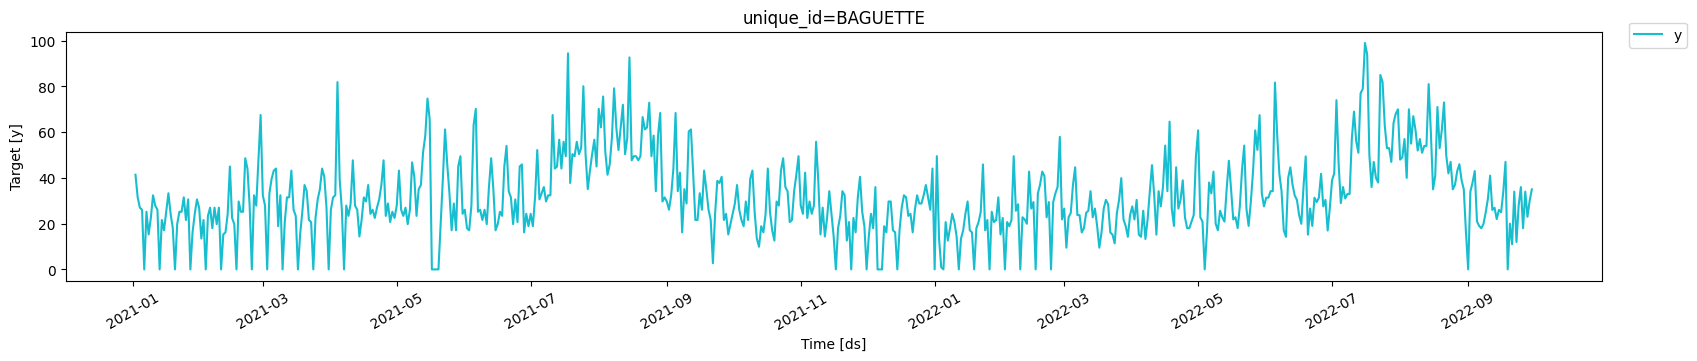

In [7]:
plot_series(df)

In [8]:
HORIZON = 7

nhits = NHITS(
    h=HORIZON,
    input_size=4*HORIZON,
    loss=MQLoss(level=[80,90]),
    scaler_type="robust",
    max_steps=1000,
)

nf = NeuralForecast(models=[nhits], freq="D")

nf.fit(df)

Seed set to 1


Epoch 999: 100%|██████████| 1/1 [00:00<00:00, 41.61it/s, v_num=2682, train_loss_step=0.0328, train_loss_epoch=0.0328]


In [13]:
fcsts = nf.predict()
fcsts = fcsts.rename(columns={"NHITS-median": "NHITS"})

fcsts.head()

Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 100.66it/s]


,unique_id,ds,NHITS,NHITS-lo-90,NHITS-lo-80,NHITS-hi-80,NHITS-hi-90
0,BAGUETTE,2022-10-01,47.676758,47.346172,47.650124,48.139580,48.479912
1,BAGUETTE,2022-10-02,63.073658,63.798153,62.973103,63.860004,63.304363
2,BAGUETTE,2022-10-03,20.292042,19.970444,19.693249,19.836720,21.314724
3,BAGUETTE,2022-10-04,39.988262,38.551300,39.308624,39.764351,40.865910
4,BAGUETTE,2022-10-05,41.407112,40.835934,41.209770,40.578705,42.332561


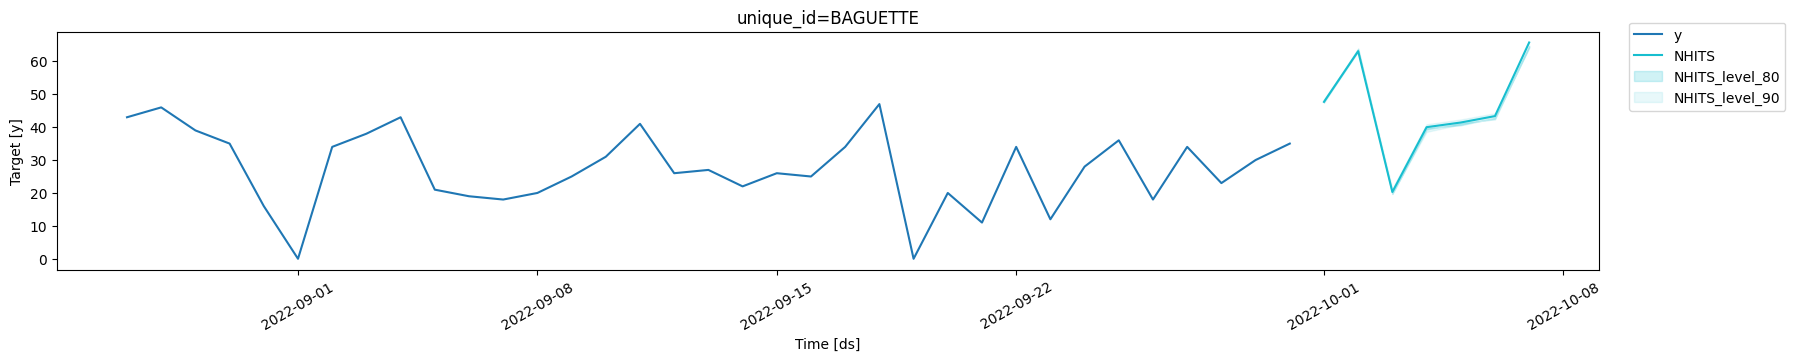

In [14]:
plot_series(df, fcsts, level=[80, 90], max_insample_length=5*HORIZON)

In [15]:
N_PATHS = 100
SEED = 42

sample_paths_df = nf.simulate(n_paths=N_PATHS, seed=SEED)

Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 111.95it/s]


In [16]:
sample_paths_df.head()

,unique_id,ds,sample_id,NHITS
0,BAGUETTE,2022-10-01,0,47.966889
1,BAGUETTE,2022-10-02,0,63.416554
2,BAGUETTE,2022-10-03,0,19.764984
3,BAGUETTE,2022-10-04,0,39.536488
4,BAGUETTE,2022-10-05,0,40.894238


In [18]:
def plot_sample_paths_intervals(df, sample_paths_df, unique_id, n_hist=90, model_col="NHITS"):                                        
    series_df = df[df["unique_id"] == unique_id].tail(n_hist)                                                                       
    paths = sample_paths_df[sample_paths_df["unique_id"] == unique_id]                                                              
                                                                                                                                    
    intervals = paths.groupby("ds")[model_col].quantile([0.05, 0.10, 0.90, 0.95]).unstack()                                         
    intervals.columns = ["lo_90", "lo_80", "hi_80", "hi_90"]                                                                        
    intervals = intervals.reset_index()                                                                                             
                                                                                                                                    
    median = paths.groupby("ds")[model_col].median().reset_index()                                                                  
                
    fig, ax = plt.subplots(figsize=(12, 5))                                                                                         
                
    ax.plot(series_df["ds"], series_df["y"], color="black", label="Historical")                                                     
    ax.plot(median["ds"], median[model_col], color="#1f77b4", label="Median forecast")
    ax.fill_between(intervals["ds"], intervals["lo_80"], intervals["hi_80"],                                                        
                    alpha=0.4, color="#1f77b4", label="80% PI")                                                                     
    ax.fill_between(intervals["ds"], intervals["lo_90"], intervals["hi_90"],                                                        
                    alpha=0.2, color="#1f77b4", label="90% PI")                                                                     
                
    ax.set_title(f"{unique_id} — Simulation paths with prediction intervals")                                                       
    ax.set_xlabel("Date")
    ax.set_ylabel("Sales")                                                                                                          
    ax.legend() 
    plt.tight_layout()
    plt.show()                                                                                                                      

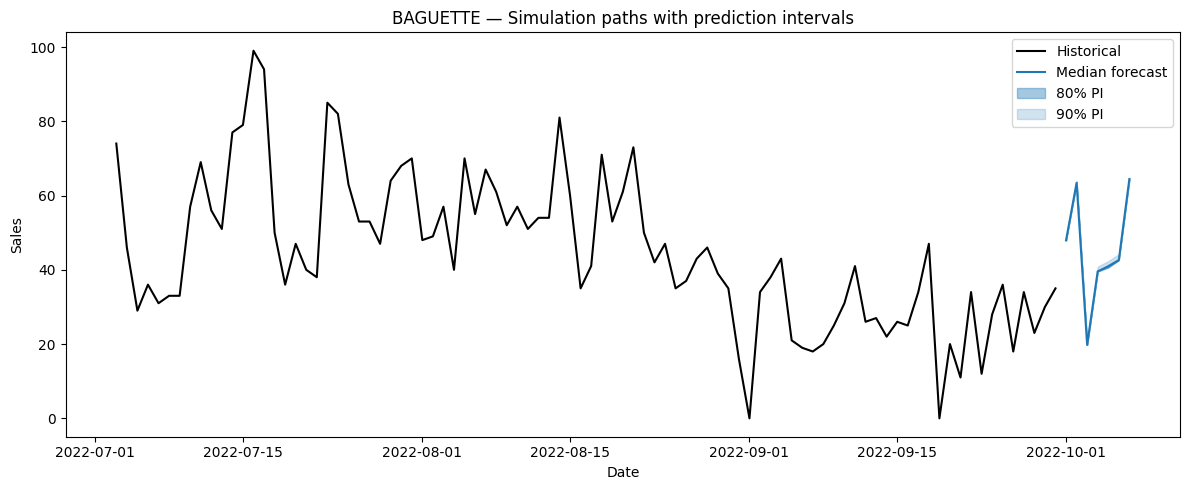

In [19]:
plot_sample_paths_intervals(df, sample_paths_df, unique_id="BAGUETTE")

### How many baguettes should be baked to serve at least 80% of the customers in the next 7 days?

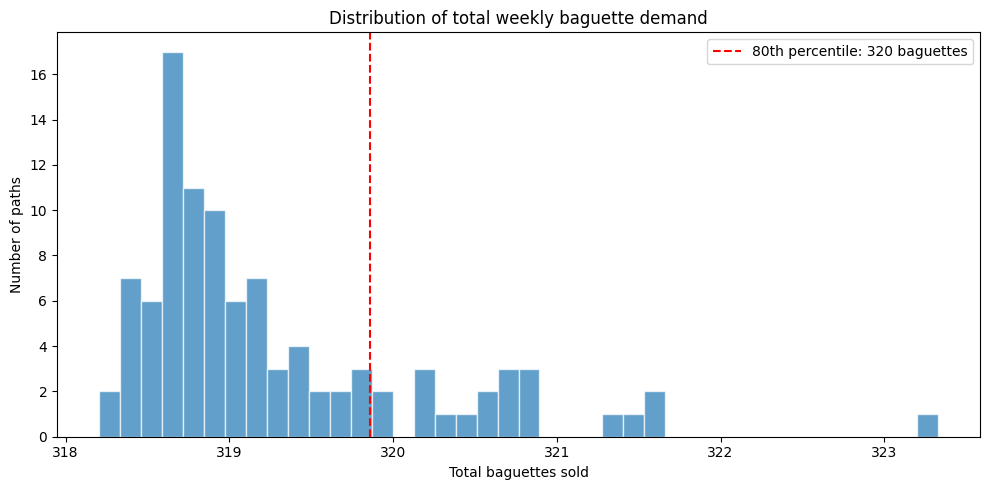

Bake 320 baguettes to serve 80% of weekly demand


In [20]:
weekly_demand = sample_paths_df.groupby("sample_id")["NHITS"].sum()                                                                 
target = weekly_demand.quantile(0.80)                                                                                               
                                                                                                                                    
fig, ax = plt.subplots(figsize=(10, 5))                                                                                             
                                                                                                                                    
ax.hist(weekly_demand, bins=40, color="#1f77b4", alpha=0.7, edgecolor="white")                                                      
ax.axvline(target, color="red", linestyle="--", label=f"80th percentile: {target:.0f} baguettes")                                   
                                                                                                                                    
ax.set_title("Distribution of total weekly baguette demand")                                                                        
ax.set_xlabel("Total baguettes sold")                                                                                               
ax.set_ylabel("Number of paths")                                                                                                    
ax.legend()                                                                                                                         
plt.tight_layout()                                                                                                                  
plt.show()                                                                                                                          
                                                                                                                                    
print(f"Bake {target:.0f} baguettes to serve 80% of weekly demand") 

## What's the expected worst day (lowest sales) in the next 7 days

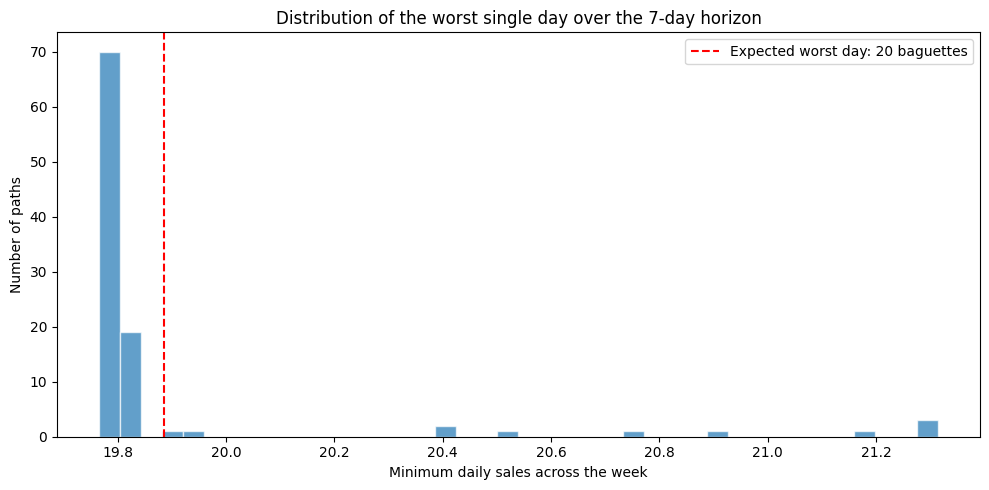

Expected worst single day: 20 baguettes


In [ ]:
worst_day = sample_paths_df.groupby("sample_id")["NHITS"].min()
expected_worst = worst_day.mean()

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(worst_day, bins=40, color="#1f77b4", alpha=0.7, edgecolor="white")
ax.axvline(expected_worst, color="red", linestyle="--", label=f"Expected worst day: {expected_worst:.0f} baguettes")                

ax.set_title("Distribution of the worst single day over the 7-day horizon")
ax.set_xlabel("Minimum daily sales across the week")
ax.set_ylabel("Number of paths")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Expected worst single day: {expected_worst:.0f} baguettes")